<a href="https://colab.research.google.com/github/ericiortega/aipi590-xai-fall2025/blob/main/assignments/machine_learning_court/court.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Court: Recidivism Prediction (Defense)

**Course:** AIPI 590 – Emerging Trends in Explainable AI (Fall 2025)  
**Professor:** Dr. Brinnae Bent  
**Author:** Eric Ortega Rodriguez  
**Case Domain:** Recidivism Prediction  
**Assigned Role:** Defense  
**Dataset:** [COMPAS Recidivism Dataset](https://github.com/propublica/compas-analysis)  
**Deadline:** September 22, 2025  
**GitHub Repo:** [Assignment Folder](https://github.com/ericiortega/aipi590-xai-fall2025)  

---

## Introduction & Case Context
In this notebook, I will analyze the use of recidivism prediction models through the COMPAS dataset.
The main focus is on Malik Johnson who is a 27-year-old with one prior felony who was flagged as low risk and granted parole.  
Some have questioned whether this was an appropriate classification

My role and goal is to argue **for the Defense**. I will use at **two XAI methods (SHAP and LIME)** to show why the decision was reasonable and correct through the use of interpretable features.

### 🔴 Prosecution (Counter-Role)
Would argue that the model underestimated risk factors and might expose flaws or inconsistencies.  

### 🔵 Defense (My Role)
Argues that the model’s low-risk prediction is valid.
I will demonstrate that:  
- The model relies on logical and transparent features (age, priors, charge degree).  
- Both SHAP and LIME explanations show that Malik’s characteristics support the low risk classification



> Import Libraries & Load data

In [ ]:
#importing libraries and loading data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import shap
from lime import lime_tabular

# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_raw = pd.read_csv(url)

print(df_raw.shape)
df_raw.head()


(7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


> Visualizations to help with data exploration

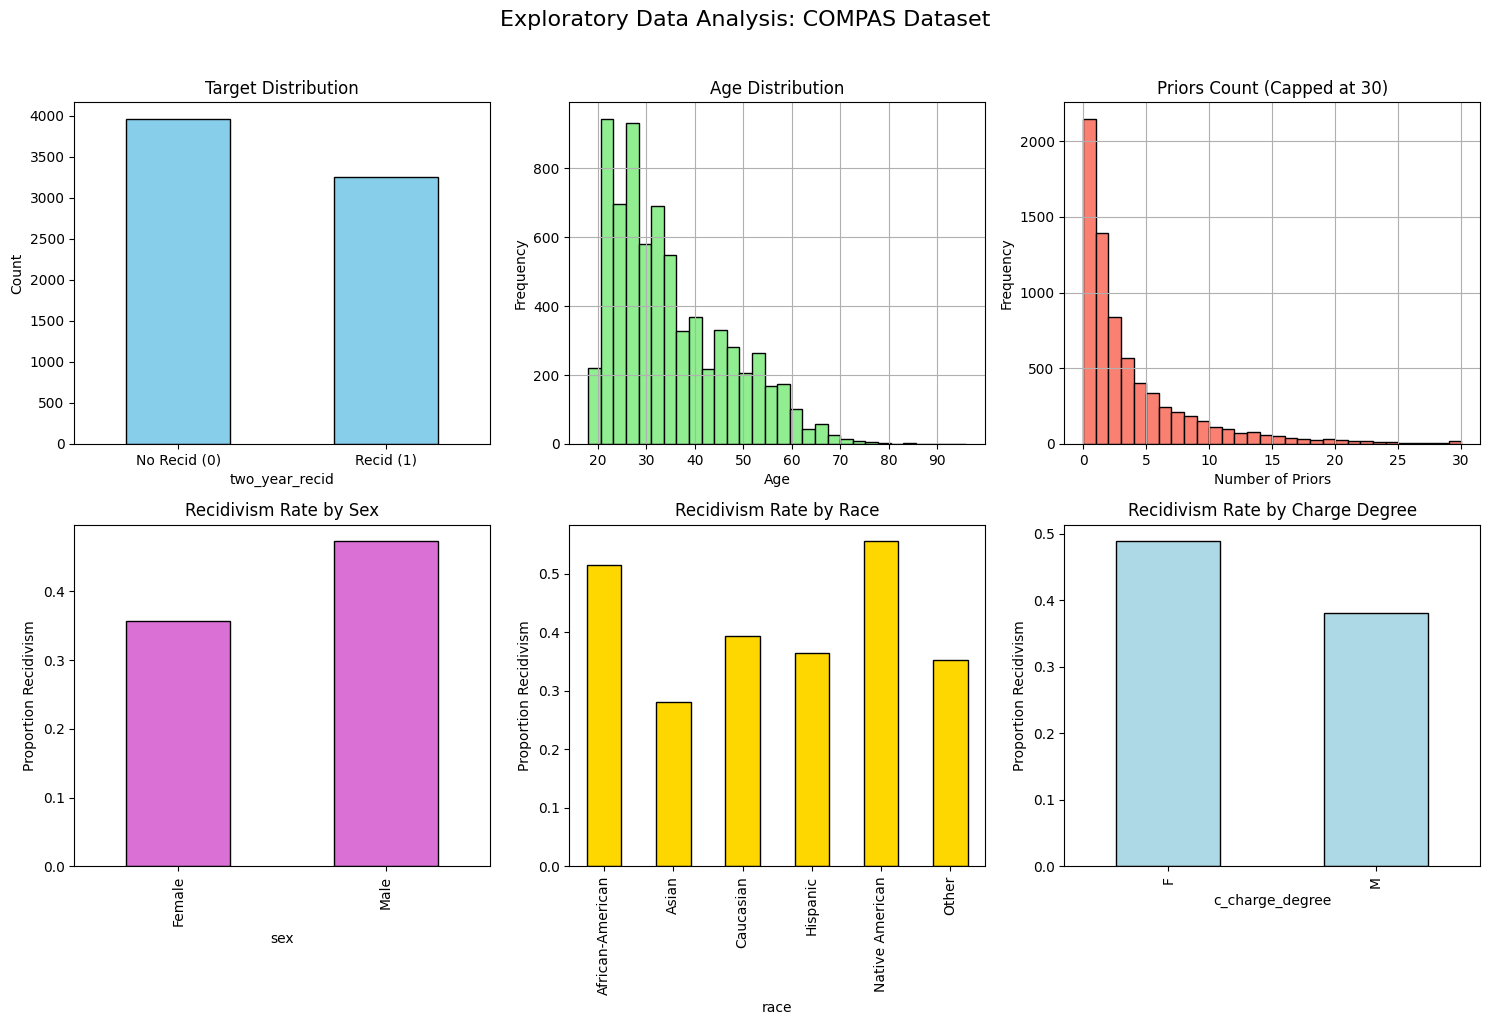

In [ ]:
# EDA Visualization
# Note: I used ChatGPT (Sept 17, 2025, 1:45 PM) to help organize multiple EDA charts into a single figure for clarity.

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Exploratory Data Analysis: COMPAS Dataset", fontsize=16, y=1.02)

# 1. Target distribution
df_raw['two_year_recid'].value_counts().plot(kind='bar', ax=axes[0,0], color="skyblue", edgecolor="black")
axes[0,0].set_title("Target Distribution")
axes[0,0].set_xticklabels(["No Recid (0)", "Recid (1)"], rotation=0)
axes[0,0].set_ylabel("Count")

# 2. Age distribution
df_raw['age'].hist(bins=30, ax=axes[0,1], color="lightgreen", edgecolor="black")
axes[0,1].set_title("Age Distribution")
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("Frequency")

# 3. Priors count distribution
df_raw['priors_count'].clip(upper=30).hist(bins=30, ax=axes[0,2], color="salmon", edgecolor="black")
axes[0,2].set_title("Priors Count (Capped at 30)")
axes[0,2].set_xlabel("Number of Priors")
axes[0,2].set_ylabel("Frequency")

# 4. Recidivism by Sex
df_raw.groupby('sex')['two_year_recid'].mean().plot(kind='bar', ax=axes[1,0], color="orchid", edgecolor="black")
axes[1,0].set_title("Recidivism Rate by Sex")
axes[1,0].set_ylabel("Proportion Recidivism")

# 5. Recidivism by Race
df_raw.groupby('race')['two_year_recid'].mean().plot(kind='bar', ax=axes[1,1], color="gold", edgecolor="black")
axes[1,1].set_title("Recidivism Rate by Race")
axes[1,1].set_ylabel("Proportion Recidivism")

# 6. Recidivism by Charge Degree
df_raw.groupby('c_charge_degree')['two_year_recid'].mean().plot(kind='bar', ax=axes[1,2], color="lightblue", edgecolor="black")
axes[1,2].set_title("Recidivism Rate by Charge Degree")
axes[1,2].set_ylabel("Proportion Recidivism")

plt.tight_layout()
plt.show()


### Random Forest Model (Given by Dr. Bent)

In [ ]:
# code from Dr. Bent
# ⚖️ Case 3: Recidivism Prediction (COMPAS Dataset)
df_compas = pd.read_csv(url)

# Filter relevant columns and preprocess
features = ['age', 'sex', 'race', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree']
df = df_compas[features + ['two_year_recid']].dropna()
df = df[df['c_charge_degree'].isin(['F', 'M'])]  # Filter valid degrees

# My addition: want to capture cartgeory names before encoding

cat_cols = ['sex', 'race', 'c_charge_degree']
cat_categories = {c: pd.Categorical(df[c]).categories.tolist() for c in cat_cols}

categorical_features_idx = [features.index(c) for c in cat_cols]
categorical_names_for_lime = {
    features.index('sex'): cat_categories['sex'],
    features.index('race'): cat_categories['race'],
    features.index('c_charge_degree'): cat_categories['c_charge_degree'],
}

# Encode categoricals
df = df.copy()
df['sex'] = df['sex'].astype('category').cat.codes
df['race'] = df['race'].astype('category').cat.codes
df['c_charge_degree'] = df['c_charge_degree'].astype('category').cat.codes

X = df[features]
y = df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_compas = RandomForestClassifier(random_state=42)
model_compas.fit(X_train, y_train)
print(classification_report(y_test, model_compas.predict(X_test)))


              precision    recall  f1-score   support

           0       0.68      0.68      0.68       823
           1       0.57      0.57      0.57       620

    accuracy                           0.63      1443
   macro avg       0.62      0.62      0.62      1443
weighted avg       0.63      0.63      0.63      1443



### Malik Johnson Prediction (Given by Dr. Bent)

In [ ]:
# 🎯 Focus Instance: Recidivism Risk Case (Malik Johnson)
focus_instance_compas = pd.DataFrame([{
    "age": 27,
    "sex": 1,  # Male
    "race": 1,  # African-American
    "priors_count": 1,
    "juv_fel_count": 0,
    "juv_misd_count": 0,
    "juv_other_count": 0,
    "c_charge_degree": 1  # Felony
}])

pred = model_compas.predict(focus_instance_compas)
print("Prediction for Malik Johnson (Recidivism):", pred)

Prediction for Malik Johnson (Recidivism): [0]


### Model Evaluation: Random Forest Confusion Matrix
The confusion matrix below shows the performance of the trained RandomForestClassifier on the test set.


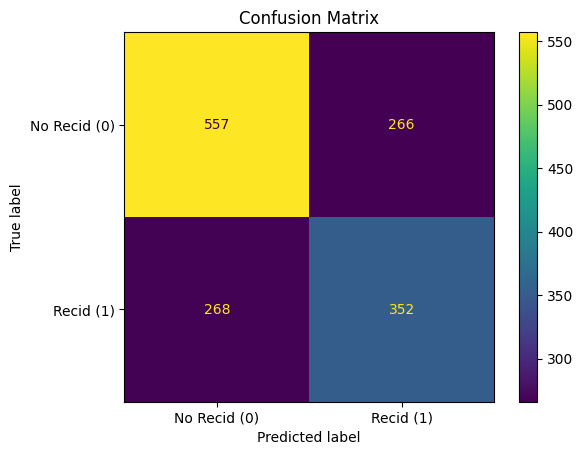

In [ ]:
y_pred = model_compas.predict(X_test)
comfusion = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(comfusion, display_labels=["No Recid (0)", "Recid (1)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()


### Confusion Matrix Analysis

|                | Prediction: No Recid | Prediction: Recid |  total |
|----------------|-----------------|-------------|-----------|
| Actual No Recid| TN = 557        | FP = 266    | 823       |
| Actual Recid   | FN = 268        | TP = 352    | 620       |
| Column totals  | 825             | 618         | 1443      |

Overall percentage breakdown (of 1,443 total):
- TN: 557 / 1443 ≈ 38.6%
- TP: 352 / 1443 ≈ 24.4%
- FP: 266 / 1443 ≈ 18.4%
- FN: 268 / 1443 ≈ 18.6%

This shows the model is somewhat better at identifying non-recidivists than recidivists.

Key metric for Malik (for predicted No Recid):
- Negative Predictive Value (NPV): NPV = TN / (TN + FN) = 557 / (557 + 268) = 557 / 825 ≈ 67.5%

Interpretation:
- NPV looks at the model’s No Recid predictions (how often those people truly did not recidivate)


### Explaining Outcome with XAI Methods

To explain Malik Johnson’s low-risk classification, I will be using  two XAI methods from our course notes: **LIME** and **SHAP**.

- LIME (Local Interpretable Model-agnostic Explanations):  
  “LIME explains predictions by learning a simple interpretable model locally around the prediction” and it “perturbs the data and observes the black box model’s responses” (week 3 slides).  
  This helps identify which features were most important in Malik’s case.

- SHAP (SHapley Additive Explanations):  
  SHAP “uses Shapley values from cooperative game theory to assign each feature a contribution to the prediction” and provides a “fair distribution of the difference between the prediction and the average prediction among the input features”(week 3 slides).  
  SHAP values show how much each feature contributed to pushing Malik’s classification toward low or high risk.


### LIME

In [ ]:
!pip install -q lime==0.2.0.1

In [ ]:
class_names   = ['No Recid','Recid']
feature_names = features
cat_cols      = ['sex','race','c_charge_degree']

categorical_features = [feature_names.index(c) for c in cat_cols]
categorical_names    = {
    feature_names.index('sex'):  cat_categories['sex'],
    feature_names.index('race'): cat_categories['race'],
    feature_names.index('c_charge_degree'): cat_categories['c_charge_degree'],
}

# make sures codes match that same category order
def code_of(val, cats):
    return cats.index(val)

# features i am using for Malik:
focus_instance_compas.loc[0, 'sex']  = code_of('Male', cat_categories['sex'])
focus_instance_compas.loc[0, 'race'] = code_of('African-American', cat_categories['race'])
focus_instance_compas.loc[0, 'c_charge_degree'] = code_of('M', cat_categories['c_charge_degree'])


#printing out the features being used that classify Malik
print("Malik decoded: ", {
    c: categorical_names[feature_names.index(c)][int(focus_instance_compas[c].iloc[0])]
    for c in cat_cols
})

# Note: I used ChatGPT (GPT-5) to understand why LIME was showing a “X does not have valid feature names” warning and how to fix it.
def predict_proba_df(x):
    if isinstance(x, np.ndarray):
        x = pd.DataFrame(x, columns=feature_names)
    elif isinstance(x, pd.Series):
        x = x.to_frame().T
    return model_compas.predict_proba(x)

#Explainer (from dr.bents code)
kernel_width = 3
explainer = lime_tabular.LimeTabularExplainer(
    X_train.values,
    class_names=class_names,
    feature_names=feature_names,
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    kernel_width=kernel_width,
    discretize_continuous=True,
    mode='classification'
)

# Malik explanation
instance = focus_instance_compas[feature_names].values[0]
exp = explainer.explain_instance(
    instance,
    predict_proba_df,
    num_features=10
)

exp.show_in_notebook(show_table=True)

# Parts of the above code were adapted with assistance from ChatGPT (GPT-5) on 09/21/25 at 7:00 p.m.
# I primarily wrote and structured the notebook myself, and used ChatGPT only to help refine the mappings and formatting for the LIME explanation.


Malik decoded:  {'sex': 'Male', 'race': 'African-American', 'c_charge_degree': 'M'}


> ### LIME Findings (Malik Johnson)  
>  
> Prediction Probabilities:  
> - No Recid: 0.94
> - Recid: 0.06
>  
> LIME highlights that Malik’s clean juvenile record (`juv_fel_count = 0`, `juv_misd_count = 0`, `juv_other_count = 0`) and low prior record (`priors_count = 1`) are the strongest features pushing toward No Recid (in blue color).
>  
> The features pushing toward Recid (orange) are:  
> - Age = 27 (younger age slightly increases risk)  
> - Sex = Male  
> - Charge Degree = M (Felony)  
>  
> Overall:
> The protective pattern (clean juvenile record and low priors) outweighs the small risk pushes, which justifies the model’s low-risk classification.


### SHAP

Next, I will look into SHAP (SHapley Additive exPlanations).  

I will use SHAP in two ways:  
1. **Global explanation** – to see which features are most important across the entire dataset in driving recidivism predictions
2. **Local explanation for Malik Johnson** – to confirm whether his individual prediction (low risk) is explained by protective features (meaning his no juvenile record and limited priors) rather than risk factors like gender or age


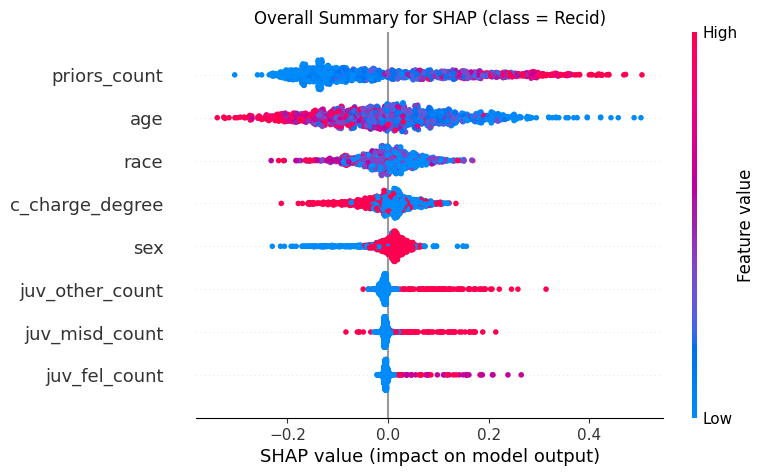

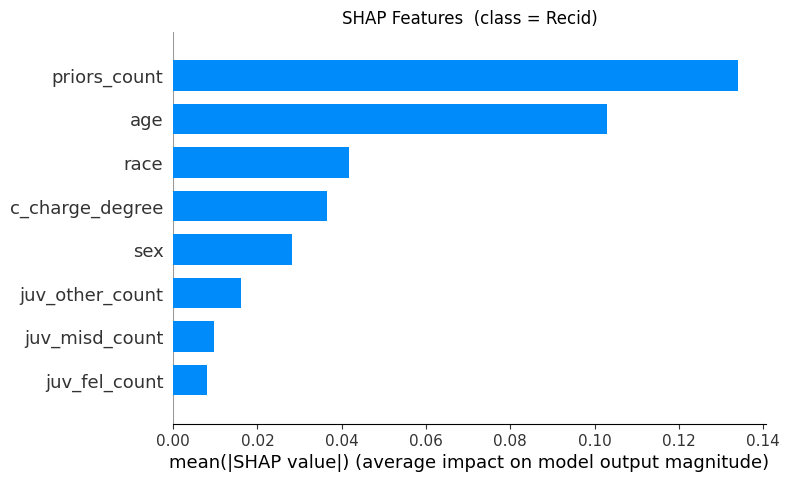

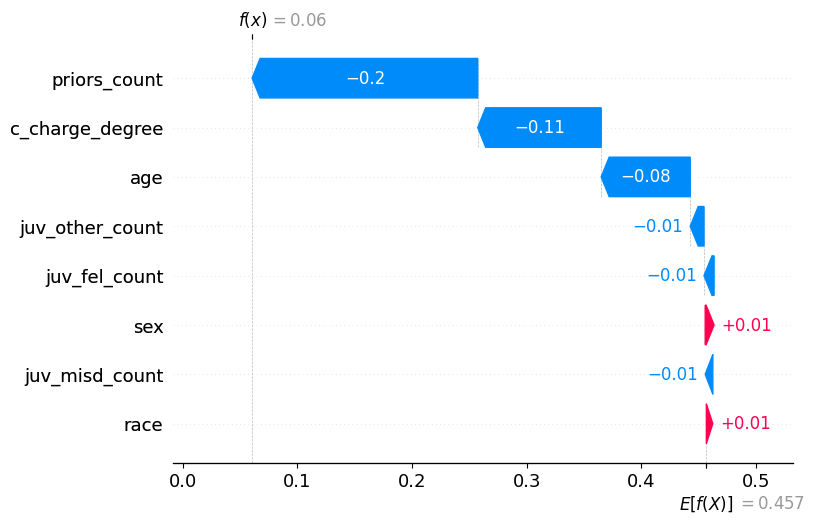

P(Recid) = 0.06


In [ ]:
# inputs
X_test_df = pd.DataFrame(X_test, columns=features)
malik_df  = focus_instance_compas[features].iloc[[0]]
pos_idx   = int(np.where(model_compas.classes_ == 1)[0][0])

explainer = shap.TreeExplainer(model_compas)

sv_matrix, _ = extract_sv_matrix(explainer, X_test_df, pos_idx)

shap.summary_plot(sv_matrix, X_test_df, show=False)
plt.title("Overall Summary for SHAP (class = Recid)")
plt.show()

shap.summary_plot(sv_matrix, X_test_df, plot_type="bar", show=False)
plt.title("SHAP Features  (class = Recid)")
plt.show()

# waterfalll
malik_vals, malik_base = extract_sv_local(explainer, malik_df, pos_idx)
shap.plots._waterfall.waterfall_legacy(malik_base, malik_vals, feature_names=features)

# printing
print(f"P(Recid) = {model_compas.predict_proba(malik_df)[0][pos_idx]:.2f}")

# Note: ChatGPT (GPT-5) was used to help understand sections of Dr. Bent’s code and refine formatting; I wrote and adapted the final code myself.


> ### SHAP Findings (Malik Johnson)  
>  
> Most influential features are:
> 1. priors_count
> 2. age
> 3. race
> 4. c_charge_degree
> 5. sex
>  
> Juvenile counts contribute very little overall. This suggests the model relies primarily on behavioral history (priors) and some contextual variables rather than demographics alone
>  
> Local (Malik Johnson):  
> Malik’s prediction for Recid is low. Looking at the SHAP waterfall for class = Recid shows a decrease from the baseline toward a lower risk score, driven mainly by:
>
> - priors_count = 1 (−0.20), strongly reducing risk  
> - c_charge_degree = M (−0.11), reducing risk  
> - age = 27 (−0.08), reducing risk
> - juvenile counts = 0, each adding small negative contributions  
> - sex = Male (+0.01) and race = African-American (+0.01), providing very small positive pushes
>  
> Overall:  
> SHAP confirms that Malik’s limited prior record and clean juvenile history dominate the prediction and decrease the risk score. Ultimately, this helps supports our defense position that classifying Malik as low risk is consistent with the model’s reasoning and can now back it up with SHAP.


### Conclusion  
  
Both LIME and SHAP findings align with the prediction for Malik. His profile is dominated by various postive factors. His one prior count and clean juvenile history consistently pull the prediction away from recid. On the other hand there is a small push to the oppostie side due to age and gender. However, it is not enough to change the outcome.

In addition to this, the model’s reasoning is transparent and consistent across both explanation methods. We can see that there is a reliance on his criminal history rather than just his demographics. This observation further strengthens the credibility of the prediction the model gave.  

Taking all of this into account, the evidence supports classifying Malik as low risk. The model is reasonably accurate and explainable, which allows me to confidently conclude that the low-risk classification is justified.


# Logic for Trial ⚖️

### Claim
Malik Johnson should be considered low risk for recidivism.

### Key evidence
- NPV (relevant to “No Recid” predictions): 557 / (557 + 268) = 557 / 825 ≈ 67.5%.
- Malik’s individualized risk: P(Recid | Malik) ≈ 0.06 ; P(No Recid | Malik) ≈ 0.94.
- LIME (local): clean juvenile record and low priors push strongly toward No Recid.
- SHAP (global): priors_count is the top driver; demographics are minor for Malik.
- Confusion matrix trend: model identifies non-recidivists reasonably well.

### Conclusion
Malik’s low-risk classification is consistent, explainable, and supported by both local and global evidence.
